# Aurora Inference + Rollout (Fine-Tuned Model)

This notebook provides inference/rollout using a **fine-tuned Aurora checkpoint**.

Workflow:
1. Load YAML config
2. Load test dataset
3. Initialize model with fine-tuned checkpoint
4. Run rollout predictions
5. Save predictions and plots

## Environment / Imports

In [1]:
# Setup: Add project root to Python path
import sys
from pathlib import Path

# Get the project root (parent of finetune directory)
notebook_dir = Path.cwd()
if notebook_dir.name == 'finetune':
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')

Project root: /mnt/data3/aurora


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr

import finetune.aurora_finetune_utils as ft
from aurora import (
    Aurora,
    Aurora12hPretrained,
    AuroraAirPollution,
    AuroraHighRes,
    AuroraPretrained,
    AuroraSmallPretrained,
    AuroraWave,
)

## Configuration

In [3]:
# ============================================================================
# CONFIGURATION: Edit these settings
# ============================================================================

# Configuration file (auto-detects location)
CONFIG_PATH_NAME = 'aurora_finetune_rollout_config.yaml'
if Path(CONFIG_PATH_NAME).exists():
    CONFIG_PATH = Path(CONFIG_PATH_NAME)
elif (Path('finetune') / CONFIG_PATH_NAME).exists():
    CONFIG_PATH = Path('finetune') / CONFIG_PATH_NAME
else:
    raise FileNotFoundError(f'Config file {CONFIG_PATH_NAME} not found')

# Path to your fine-tuned checkpoint and output dir.
# Defaults derive from the YAML's `case_name` so artifacts land under
# outputs/<case_name>/ and outputs/checkpoints/<case_name>/, matching
# what aurora_finetune_distributed.py wrote during training. Set these
# explicitly to override.
CHECKPOINT_PATH = None  # None = outputs/checkpoints/<case_name>/best.ckpt

# Rollout configuration (can override config YAML)
ROLLOUT_NUM_STEPS = None  # None = use config value
ROLLOUT_START_SAMPLE_INDEX = 0  # Used when ROLLOUT_START_TIME is None
ROLLOUT_START_TIME = None  # Example: '2020-01-01T00:00:00' (must match anchor time)

# Output settings
SAVE_NETCDF = True
SAVE_PLOTS = True
OUTPUT_DIR = None  # None = outputs/<case_name>/ (or outputs/inference if no case_name)

# ============================================================================

cfg = ft.load_config(CONFIG_PATH)
_case = str(cfg.get('case_name', '')).strip()
if CHECKPOINT_PATH is None:
    CHECKPOINT_PATH = str(Path(cfg['paths']['checkpoint_dir']) / 'best.ckpt')
if OUTPUT_DIR is None:
    OUTPUT_DIR = cfg['paths']['output_dir'] if _case else 'outputs/inference'
print(f"Loaded config from: {CONFIG_PATH.resolve()}")
print(f"Case name: {_case or '(none)'}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Loaded config from: /mnt/data3/aurora/finetune/aurora_finetune_rollout_config.yaml
Case name: two-day_lead
Checkpoint: /mnt/data3/aurora/finetune/outputs/checkpoints/two-day_lead/best.ckpt
Output dir: /mnt/data3/aurora/finetune/outputs/two-day_lead


## Load Test Dataset

In [4]:
test_ds = ft.open_dataset(cfg['paths']['test_data_path'], cfg)

# Merge static variables from external pickle (lsm, z, slt) into the test dataset.
static_path = cfg['paths'].get('static_data_path', '')
if static_path:
    test_ds = ft.merge_external_static_vars(test_ds, static_path, cfg)
    print(f'Merged static vars from: {static_path}')

resolved_specs = ft.resolve_variable_specs(test_ds, cfg)

print('Test dataset sizes:', test_ds.sizes)
print('Predictors:', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.predictors])
print('Targets:   ', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.targets])
print('Static:    ', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.static])

Merged static vars from: /mnt/data3/cams/aurora-0.4-air-pollution-static.pickle
Test dataset sizes: Frozen({'time': 8, 'latitude': 63, 'longitude': 188, 'level': 13})
Predictors: ['t2m->2t (surf)', 'u10->10u (surf)', 'v10->10v (surf)', 'msl->msl (surf)', 'tcno2->tcno2 (surf)', 'z->z (atmos)', 'u->u (atmos)', 'v->v (atmos)', 't->t (atmos)', 'q->q (atmos)', 'no2->no2 (atmos)']
Targets:    ['no2->no2 (atmos)', 'tcno2->tcno2 (surf)']
Static:     ['lsm->lsm (static)', 'z_static->z (static)', 'slt->slt (static)', 'static_ammonia->static_ammonia (static)', 'static_ammonia_log->static_ammonia_log (static)', 'static_co->static_co (static)', 'static_co_log->static_co_log (static)', 'static_nox->static_nox (static)', 'static_nox_log->static_nox_log (static)', 'static_so2->static_so2 (static)', 'static_so2_log->static_so2_log (static)']


## Build Test Samples

In [5]:
# For rollout inference we only need input_time_steps history frames to seed the model.
# Unlike training, there is no target lead-time tail constraint.
time_dim = cfg.get('data', {}).get('time_dim', 'time')
input_steps = int(cfg.get('data', {}).get('input_time_steps', 2))
n_time = int(test_ds.sizes[time_dim])

test_samples = [
    {
        'anchor_index': anchor_idx,
        'history_indices': list(range(anchor_idx - input_steps + 1, anchor_idx + 1)),
        'target_indices': {},
    }
    for anchor_idx in range(input_steps - 1, n_time)
]
print(f'Number of rollout start candidates: {len(test_samples)}')

if not test_samples:
    raise ValueError('No valid start positions in test dataset (need at least input_time_steps timesteps).')

# Select starting sample by time (preferred) or by index fallback
if ROLLOUT_START_TIME is not None:
    requested_time = np.datetime64(ROLLOUT_START_TIME, 's')
    anchor_times = np.asarray(
        [test_ds[time_dim].values[sample['anchor_index']] for sample in test_samples],
        dtype='datetime64[s]',
    )
    matches = np.where(anchor_times == requested_time)[0]

    if matches.size == 0:
        nearest_idx = int(np.argmin(np.abs(anchor_times - requested_time)))
        nearest_time = anchor_times[nearest_idx]
        raise ValueError(
            f'ROLLOUT_START_TIME={requested_time} is not a valid anchor time. '
            f'Nearest available anchor is {nearest_time} at sample index {nearest_idx}.'
        )

    rollout_idx = int(matches[0])
else:
    rollout_idx = max(0, min(ROLLOUT_START_SAMPLE_INDEX, len(test_samples) - 1))

start_sample = test_samples[rollout_idx]
anchor_time = np.datetime64(test_ds[time_dim].values[start_sample['anchor_index']], 's')
history_times = [
    np.datetime64(test_ds[time_dim].values[idx], 's')
    for idx in start_sample['history_indices']
]

print(f'Using rollout start candidate {rollout_idx}')
print(f'  Anchor index: {start_sample["anchor_index"]}')
print(f'  Anchor time: {anchor_time}')
print(f'  History indices: {start_sample["history_indices"]}')
print(f'  History times: {history_times}')

Number of rollout start candidates: 7
Using rollout start candidate 0
  Anchor index: 1
  Anchor time: 2026-04-01T12:00:00
  History indices: [0, 1]
  History times: [np.datetime64('2026-04-01T00:00:00'), np.datetime64('2026-04-01T12:00:00')]


## Initialize Model

In [6]:
MODEL_REGISTRY = {
    'aurora': Aurora,
    'aurora_pretrained': AuroraPretrained,
    'aurora_small_pretrained': AuroraSmallPretrained,
    'aurora_12h_pretrained': Aurora12hPretrained,
    'aurora_highres': AuroraHighRes,
    'aurora_air_pollution': AuroraAirPollution,
    'aurora_wave': AuroraWave,
}

model_cfg = cfg['model']
variant = str(model_cfg.get('model_variant', 'aurora_pretrained')).lower()

if variant not in MODEL_REGISTRY:
    raise ValueError(f'Unsupported model variant: {variant}. Available: {sorted(MODEL_REGISTRY)}')

model_var_cfg = ft.derive_model_variable_config(resolved_specs, cfg)
model_kwargs = dict(model_cfg.get('model_kwargs', {}))

if 'patch_size' in model_cfg and 'patch_size' not in model_kwargs:
    model_kwargs['patch_size'] = int(model_cfg['patch_size'])

mixed_precision_mode = str(model_cfg.get('mixed_precision', 'none')).lower()
if 'autocast' not in model_kwargs:
    model_kwargs['autocast'] = mixed_precision_mode in {'bf16', 'bfloat16', 'fp16'}

model = MODEL_REGISTRY[variant](
    surf_vars=model_var_cfg['surf_vars'],
    static_vars=model_var_cfg['static_vars'],
    atmos_vars=model_var_cfg['atmos_vars'],
    **model_kwargs,
)

# Wrap with refinement heads if enabled in config (must match training architecture).
model = ft.maybe_wrap_conv_refine(model, cfg, resolved_specs)
model = ft.maybe_wrap_flow_refine(model, cfg, resolved_specs)

print(f'Initialized {variant} model (conv_refine={bool(model_cfg.get("conv_refine_enabled", False))}, flow_refine={bool(model_cfg.get("flow_refine_enabled", False))})')

Initialized aurora_air_pollution model (conv_refine=False, flow_refine=True)


## Load Fine-Tuned Checkpoint

In [7]:
import subprocess as _sp

checkpoint_path = Path(CHECKPOINT_PATH).expanduser()
if not checkpoint_path.exists():
    raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

# Pick the idle GPU with the most free memory using nvidia-smi
def _pick_best_gpu():
    try:
        out = _sp.check_output(
            ['nvidia-smi', '--query-gpu=index,memory.free',
             '--format=csv,noheader,nounits'], text=True)
    except Exception:
        return 0
    best_idx, best_free = 0, 0
    for line in out.strip().splitlines():
        parts = line.split(',')
        idx, free = int(parts[0]), float(parts[1])
        if free > best_free:
            best_idx, best_free = idx, free
    print(f'Auto-selected GPU {best_idx} ({best_free/1024:.1f} GB free)')
    return best_idx

if torch.cuda.is_available():
    device = torch.device(f'cuda:{_pick_best_gpu()}')
else:
    print('CUDA unavailable; falling back to CPU.')
    device = torch.device('cpu')

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Restore norm stats for flow-refine wrapper (if applicable). Prefer
# stats persisted in the checkpoint; fall back to recomputing from
# train data if the checkpoint predates norm-stat persistence.
try:
    from finetune.flow_refine import AuroraFlowRefine as _AFR
    if isinstance(model, _AFR):
        ns = checkpoint.get('norm_stats')
        if ns is None:
            print('Checkpoint has no norm_stats; recomputing from train_data_path…')
            _train_ds = ft.open_dataset(cfg['paths']['train_data_path'], cfg)
            _static_path = cfg['paths'].get('static_data_path')
            if _static_path:
                _train_ds = ft.merge_external_static_vars(_train_ds, _static_path, cfg)
            _specs = ft.resolve_variable_specs(_train_ds, cfg)
            ns = ft.compute_target_normalization_stats(_train_ds, _specs, cfg)
        model.set_norm_stats(ns)
        print(f'Set flow-refine norm stats: {list(ns.keys())}')
except Exception as _e:
    print(f'flow_refine norm-stat init skipped: {_e}')

model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f'Loaded checkpoint from: {checkpoint_path}')
print(f'  Epoch: {checkpoint.get("epoch", "N/A")}')
print(f'  Best val loss: {checkpoint.get("best_val_loss", "N/A")}')
print(f'Device: {device}')

Auto-selected GPU 2 (22.0 GB free)
Set flow-refine norm stats: ['no2', 'tcno2']
Loaded checkpoint from: /mnt/data3/aurora/finetune/outputs/checkpoints/two-day_lead/best.ckpt
  Epoch: 4
  Best val loss: 0.00448673265054822
Device: cuda:2


## Run Rollout Inference

In [8]:
# Override rollout steps if specified
if ROLLOUT_NUM_STEPS is not None:
    cfg['rollout']['rollout_num_steps'] = ROLLOUT_NUM_STEPS

rollout_steps = int(cfg['rollout'].get('rollout_num_steps', 0))
if rollout_steps <= 0:
    # Fall back to max(target_lead_times) from data config
    lead_times = cfg.get('data', {}).get('target_lead_times', [])
    if lead_times:
        rollout_steps = max(int(x) for x in lead_times)
        cfg['rollout']['rollout_num_steps'] = rollout_steps
    else:
        rollout_steps = 7
        cfg['rollout']['rollout_num_steps'] = rollout_steps
print(f'Running rollout for {rollout_steps} steps...')

predictions = ft.run_rollout(
    model=model,
    ds=test_ds,
    start_sample=start_sample,
    config=cfg,
    resolved_specs=resolved_specs,
    device=device,
)

print(f'✓ Completed {len(predictions)} rollout prediction steps')
print(f'  First prediction time: {predictions[0].metadata.time[0]}')
print(f'  Last prediction time: {predictions[-1].metadata.time[0]}')

Running rollout for 4 steps...
✓ Completed 4 rollout prediction steps
  First prediction time: 2026-04-02 00:00:00
  Last prediction time: 2026-04-03 12:00:00


## Save Predictions to NetCDF

In [9]:
output_dir = Path(OUTPUT_DIR).expanduser()
output_dir.mkdir(parents=True, exist_ok=True)

rollout_ds = None
if predictions and SAVE_NETCDF:
    rollout_path = output_dir / 'rollout_predictions.nc'
    smooth_sigma = float(cfg.get('rollout', {}).get('smooth_sigma', 0.0))
    patch_size = int(cfg.get('model', {}).get('patch_size', 3))
    rollout_ds = ft.save_predictions(
        predictions,
        rollout_path,
        save_netcdf=True,
        resolved_specs=resolved_specs,
        smooth_sigma=smooth_sigma,
        patch_size=patch_size,
    )
    print(f'✓ Saved rollout predictions: {rollout_path}')
    print(f'  Variables: {list(rollout_ds.data_vars.keys())}')
    print(f'  Shape: {rollout_ds.dims}')
    if smooth_sigma > 0:
        print(f'  Gaussian smoothing: sigma={smooth_sigma}')
else:
    print('Skipping NetCDF save (SAVE_NETCDF=False or no predictions)')

✓ Saved rollout predictions: /mnt/data3/aurora/finetune/outputs/two-day_lead/rollout_predictions.nc
  Variables: ['tcno2', 'no2']
  Shape: FrozenMappingWarningOnValuesAccess({'time': 4, 'latitude': 63, 'longitude': 186, 'level': 13})
  Gaussian smoothing: sigma=1.0


## Plot Results

✓ Saved plot: /mnt/data3/aurora/finetune/outputs/two-day_lead/rollout_no2.png


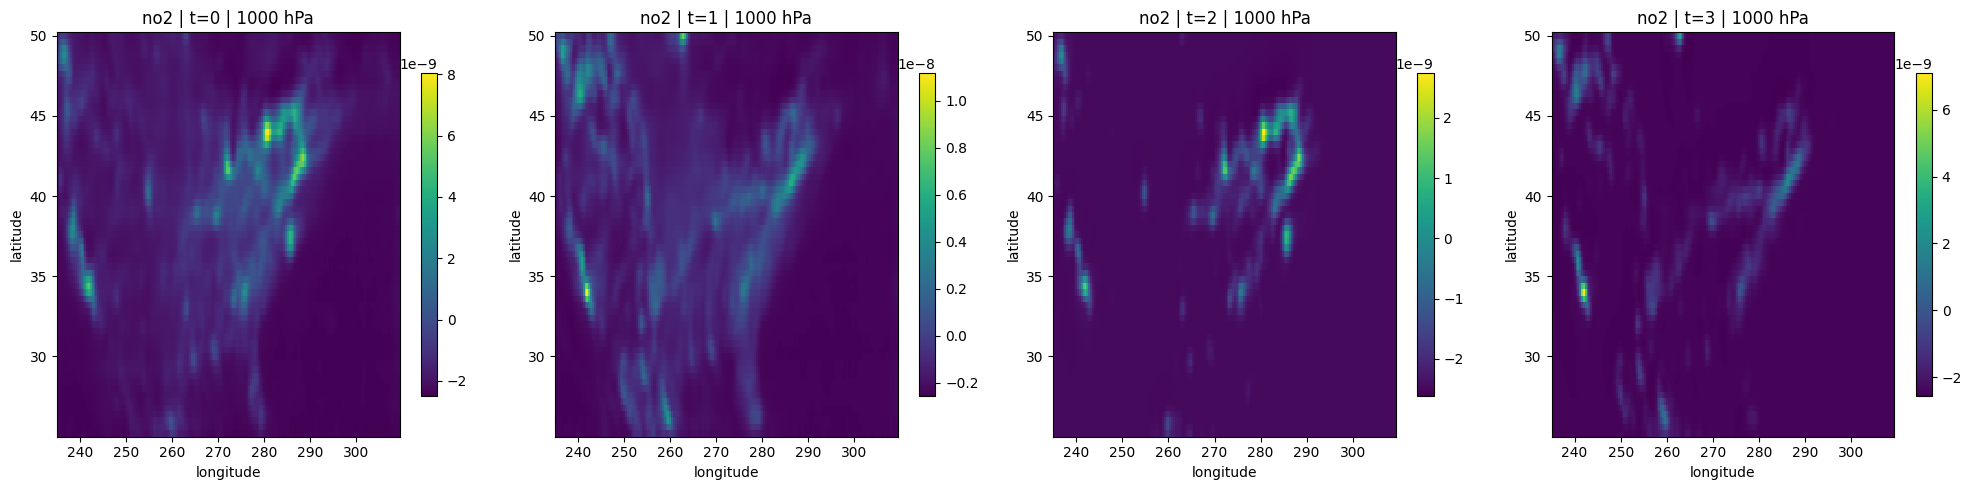

✓ Saved plot: /mnt/data3/aurora/finetune/outputs/two-day_lead/rollout_tcno2.png


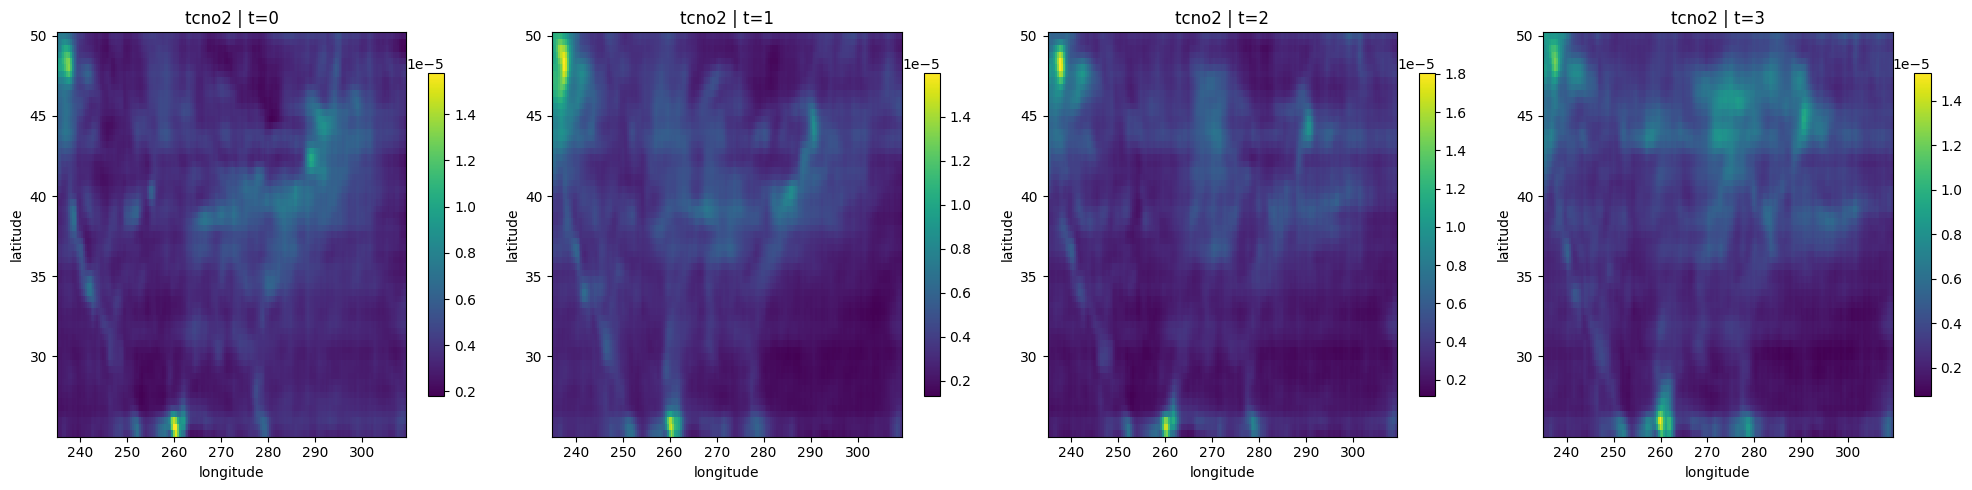

In [10]:
if rollout_ds is not None and SAVE_PLOTS:
    plot_vars = cfg.get('notebook', {}).get('plot_variables', [])
    
    if not plot_vars:
        # Default: first 3 dataset variable names
        plot_vars = list(rollout_ds.data_vars.keys())[:3]
    
    for var in plot_vars:
        if var not in rollout_ds:
            print(f'Variable {var} not in rollout dataset, skipping')
            continue

        da = rollout_ds[var]
        has_level = 'level' in da.dims

        # Plot each time step
        n_times = da.sizes.get('time', 1)
        num_steps = min(n_times, 4)
        fig, axes = plt.subplots(1, num_steps, figsize=(5 * num_steps, 5))
        if num_steps == 1:
            axes = [axes]
        
        for step_i, ax in enumerate(axes):
            if has_level:
                image = da.isel(time=step_i, level=-1)
                level_val = float(da['level'].values[-1])
                title = f'{var} | t={step_i} | {level_val:.0f} hPa'
            else:
                image = da.isel(time=step_i)
                title = f'{var} | t={step_i}'
            
            mesh = ax.pcolormesh(
                da['longitude'].values, da['latitude'].values,
                image.values, cmap='viridis', shading='auto',
            )
            fig.colorbar(mesh, ax=ax, shrink=0.8)
            ax.set_title(title)
            ax.set_xlabel('longitude')
            ax.set_ylabel('latitude')
        
        fig.tight_layout()
        fig_path = output_dir / f'rollout_{var}.png'
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'✓ Saved plot: {fig_path}')
        plt.show()
else:
    print('Skipping plots (SAVE_PLOTS=False or no rollout data)')

## Summary

In [11]:
print('\n' + '='*70)
print('INFERENCE SUMMARY')
print('='*70)
print(f'Checkpoint: {checkpoint_path}')
print(f'Test sample index: {rollout_idx}')
print(f'Rollout steps: {len(predictions)}')
print(f'Output directory: {output_dir}')
print('='*70)


INFERENCE SUMMARY
Checkpoint: /mnt/data3/aurora/finetune/outputs/checkpoints/two-day_lead/best.ckpt
Test sample index: 0
Rollout steps: 4
Output directory: /mnt/data3/aurora/finetune/outputs/two-day_lead
